# EDA: Customer Segmentation

Goal: understand the data before building the clustering pipeline.

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/train.csv")

## 1. Overview

In [23]:
df.shape

(8068, 11)

In [24]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   str    
 2   Ever_Married     7928 non-null   str    
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   str    
 5   Profession       7944 non-null   str    
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   str    
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   str    
 10  Segmentation     8068 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 918.9 KB


In [26]:
missing = pd.DataFrame({
    "missing": df.isna().sum(),
    "percent": (df.isna().mean() * 100).round(1),
})
missing = missing[missing["missing"] > 0].sort_values("missing", ascending=False)
missing

,missing,percent
Work_Experience,829,10.3
Family_Size,335,4.2
Ever_Married,140,1.7
Profession,124,1.5
Graduated,78,1.0
Var_1,76,0.9


**Conclusions:**
- 8068 customers, 11 columns.
- `ID` is an identifier and `Segmentation` is the ground-truth segment from the sales team — both are excluded from clustering features.
- 3 numeric features: `Age`, `Work_Experience`, `Family_Size`.
- 6 categorical features: `Gender`, `Ever_Married`, `Graduated`, `Profession`, `Spending_Score`, `Var_1` — they must be encoded, since KMeans works only with numbers.
- 6 columns have missing values; the largest share is in `Work_Experience` (~10%).

In [27]:
num_cols = ["Age", "Work_Experience", "Family_Size"]
cat_cols = ["Gender", "Ever_Married", "Graduated", "Profession", "Spending_Score", "Var_1"]

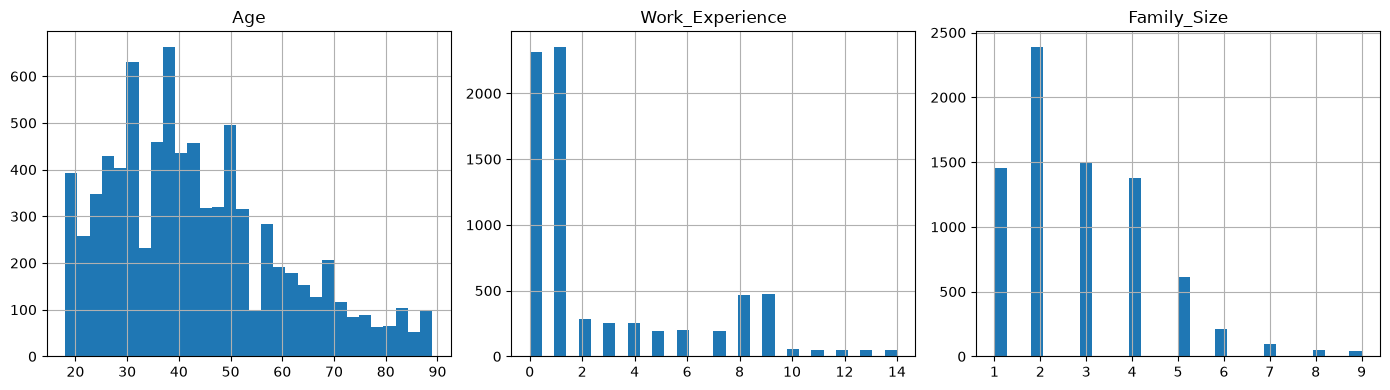

Age                0.696021
Work_Experience    1.306226
Family_Size        1.010804
dtype: float64

In [28]:
df[num_cols].hist(bins=30, figsize=(14, 4), layout=(1, 3))
plt.tight_layout()
plt.show()

df[num_cols].skew()

**Conclusions:**
- `Age` is moderately right-skewed (skew ≈ 0.70); most customers are between 25 and 50.
- `Work_Experience` is strongly right-skewed (skew ≈ 1.31): most customers have 0–1 years of experience, with a smaller second peak around 8–9 years.
- `Family_Size` is right-skewed (skew ≈ 1.01); a typical family has 1–4 members.
- For skewed features the median is a more robust central value than the mean, so missing values will be imputed with the median.

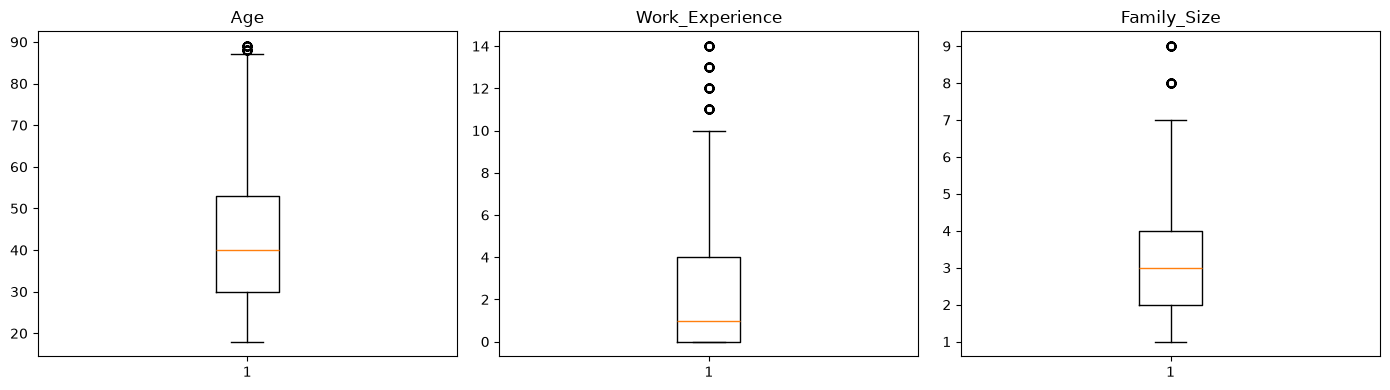

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Conclusions:**
- A few values lie beyond the whiskers: `Age` ≈ 89, `Work_Experience` 11–14, `Family_Size` 8–9.
- These look like real customers rather than data errors, so they are kept.
- KMeans is distance-based and sensitive to outliers, so `RobustScaler` (median and IQR) is preferred over `StandardScaler`.

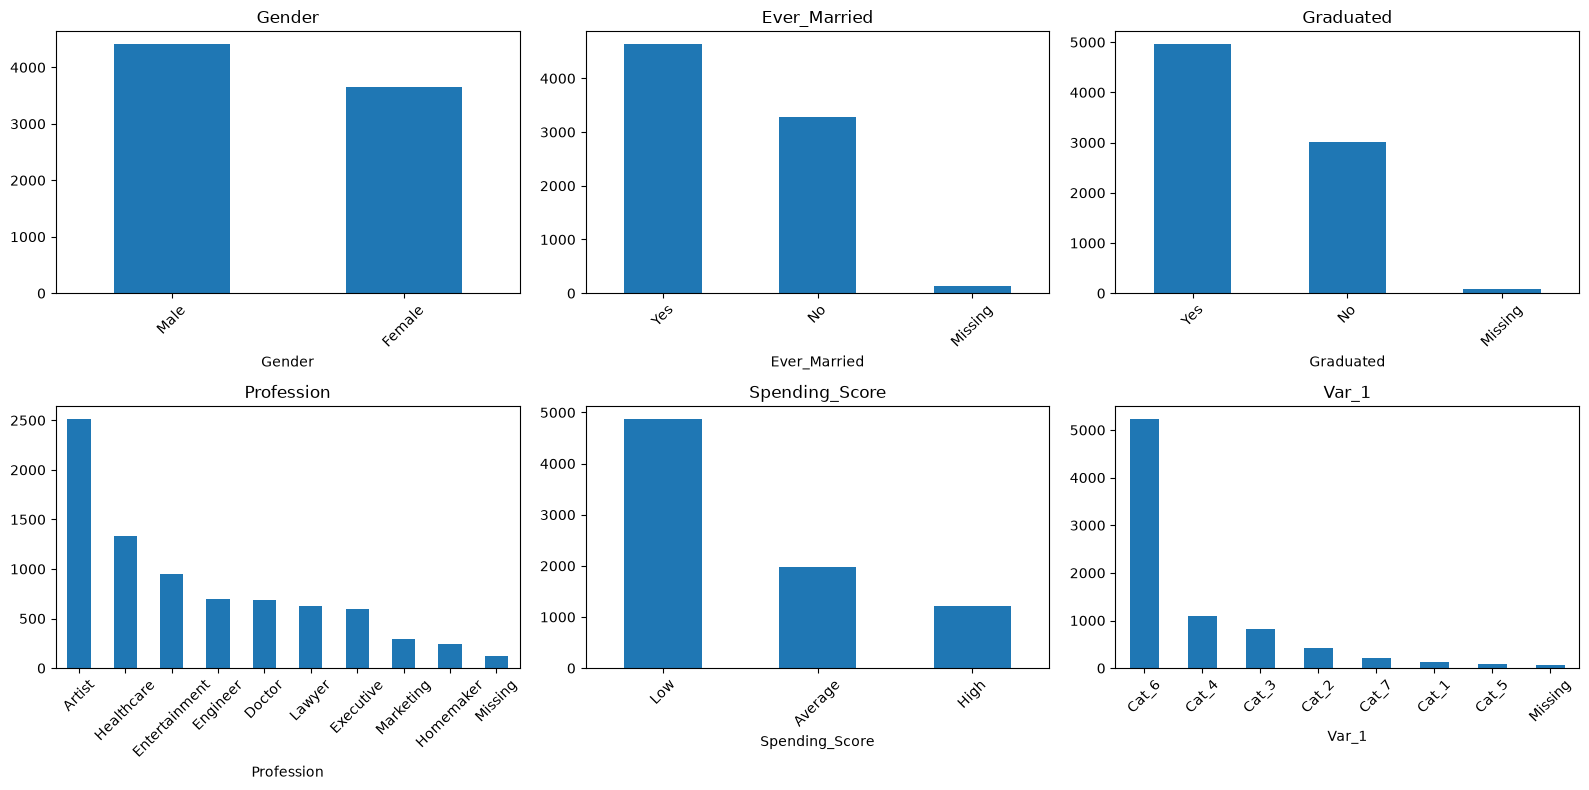

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, cat_cols):
    df[col].fillna("Missing").value_counts().plot.bar(ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Conclusions:**
- `Gender`, `Ever_Married` and `Graduated` are binary → encoded as 0/1.
- `Spending_Score` has a natural order (Low < Average < High) → ordinal encoding 1/2/3. Equal spacing between levels is an assumption, but preserving the order matters more than the equal distances one-hot encoding would impose. Most customers (~60%) have `Low`.
- `Profession` has 9 unordered categories (most common: Artist) → one-hot encoding.
- `Var_1` is an anonymised category with no known order. `Cat_6` covers ~65% of customers, while several categories are rare → one-hot encoding, with categories below 5% grouped into `Other`.

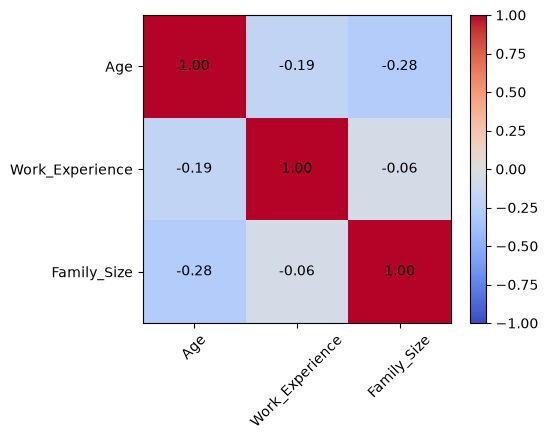

In [31]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)), num_cols, rotation=45)
ax.set_yticks(range(len(num_cols)), num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
fig.colorbar(im)
plt.show()

**Conclusions:**
- Correlations between numeric features are weak (max |r| = 0.28, `Age` vs `Family_Size`).
- The features do not duplicate each other, so PCA is not needed to remove redundancy. Its usefulness for reducing dimensionality after one-hot encoding will be tested experimentally.

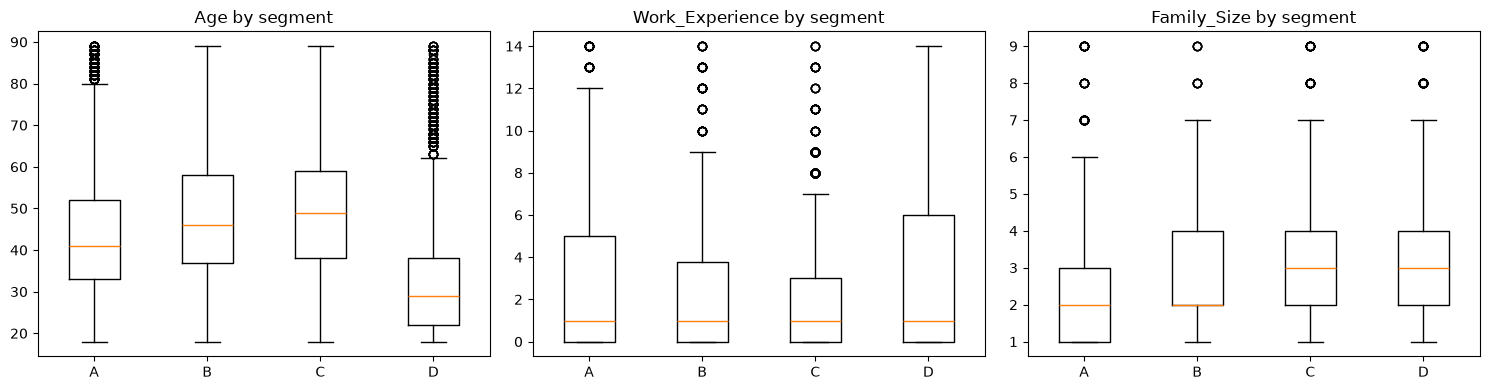

In [32]:
segments = sorted(df["Segmentation"].unique())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    data = [df.loc[df["Segmentation"] == s, col].dropna() for s in segments]
    ax.boxplot(data, tick_labels=segments)
    ax.set_title(f"{col} by segment")
plt.tight_layout()
plt.show()

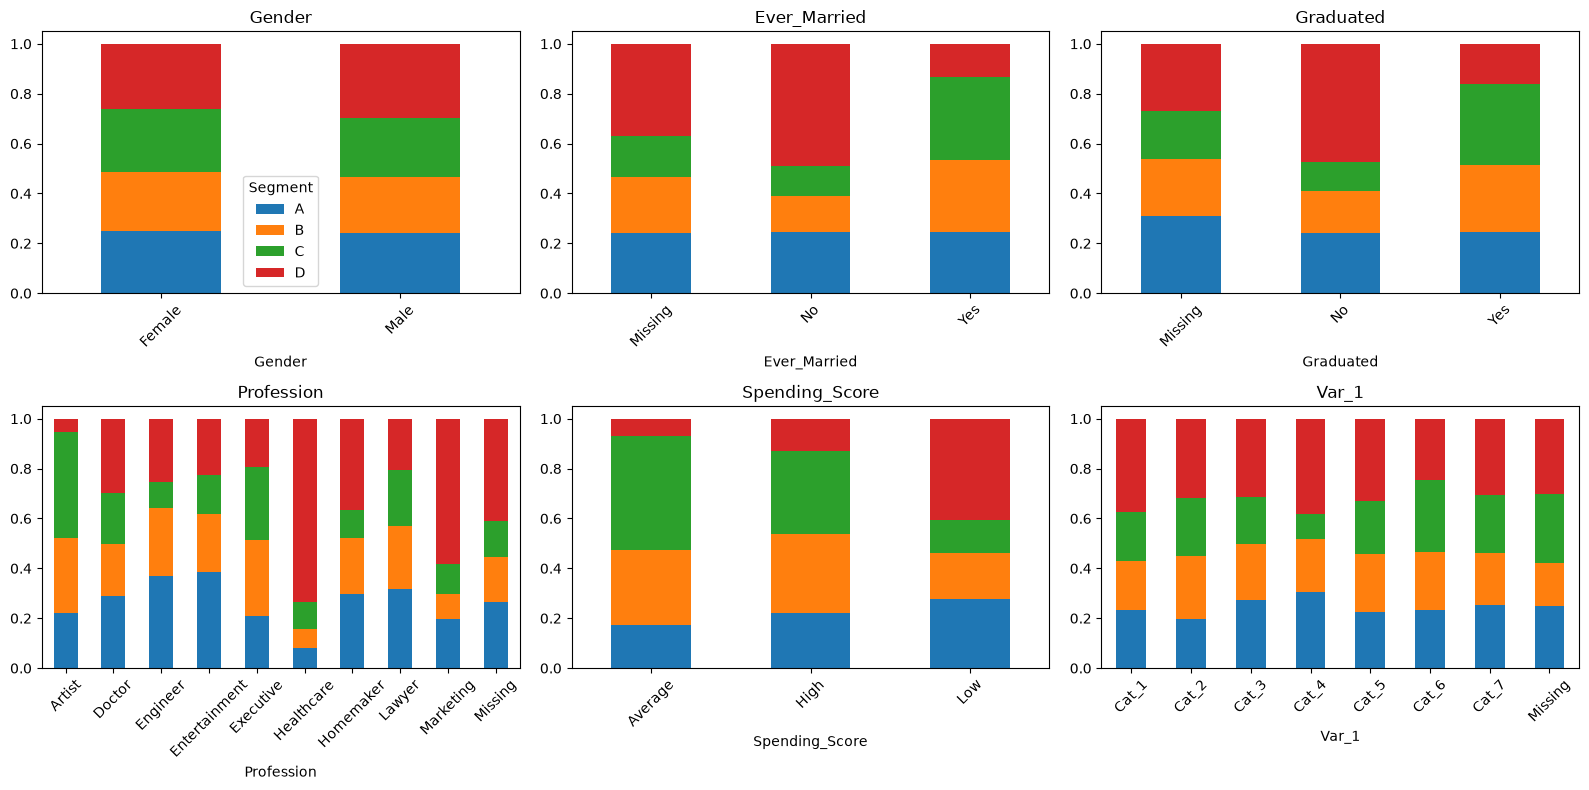

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, cat_cols):
    ct = pd.crosstab(df[col].fillna("Missing"), df["Segmentation"], normalize="index")
    ct.plot.bar(stacked=True, ax=ax, legend=False)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
axes.flat[0].legend(title="Segment")
plt.tight_layout()
plt.show()

In [34]:
for col in ["Work_Experience", "Family_Size"]:
    print(col)
    print(pd.crosstab(df[col].isna(), df["Segmentation"], normalize="index").round(2))
    print()

Work_Experience
Segmentation        A     B     C     D
Work_Experience                        
False            0.25  0.23  0.25  0.27
True             0.23  0.23  0.19  0.35

Family_Size
Segmentation     A     B     C     D
Family_Size                         
False         0.24  0.23  0.25  0.27
True          0.28  0.13  0.13  0.46



**Conclusions:**
- Customers with missing `Family_Size` belong to segment D much more often (46% vs 27%).
- For missing `Work_Experience` the effect is smaller (35% vs 27% in segment D).
- Missingness is informative, so missing-value indicators are added for both features.

In [35]:
print(df.duplicated().sum())                      
print(df.drop(columns="ID").duplicated().sum())  

0
417


## Summary: preprocessing decisions

| Step | Decision |
|---|---|
| Dropped columns | `ID` (identifier), `Segmentation` (kept aside for final comparison) |
| Numeric missing values | Median imputation + missing indicators for `Work_Experience` and `Family_Size` |
| Binary features | 0/1 encoding, missing values filled with the most frequent value |
| `Profession`, `Var_1` | One-hot encoding, missing values as a separate category, rare `Var_1` categories (<5%) → `Other` |
| `Spending_Score` | Ordinal encoding: Low=1, Average=2, High=3 |
| Scaling | `RobustScaler` for numeric features |
| PCA | Decided experimentally: with and without PCA |